# Node Conviction: correlation with degree and betweenness across checkpoints

For each training checkpoint we load the saved node norms (conviction), then compute
Spearman ρ between conviction and (i) node degree and (ii) betweenness centrality,
for every diffusion-layer snapshot X_0 … X_L.  
The result is a 2-panel figure where each curve is one checkpoint and the x-axis is the layer.

## 1. Imports

In [1]:
import os
import glob
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import spearmanr

## 2. Config

In [2]:
dataset          = "roman_empire"
model            = "BundleSheaf"
Norm             = "false"          # must match --normalised flag (true / false)
stalk_dim        = 5
layers           = 5
hidden_channels  = 16
epochs           = 500
seed             = 43
num_folds        = 10
learn_first_maps = False

# Checkpoints to analyse — order defines curve order in the plot.
# 'last' refers to the top-level (final epoch) file, not a checkpoints/ subdir.
checkpoint_names = ['epoch-0', 'epoch-1', 'epoch-5', 'epoch-15', 'epoch-200', 'best-epoch', 'last']

# ---- derived ----------------------------------------------------------------
lfm_tag = (f"_learn_first_maps-{str(learn_first_maps).lower()}"
           if model == 'JointSheafParamsAlt' else "")

BASE_NORMS = (
    f"../results/node_norms/{dataset}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
    f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs"
)

def norm_path(fold, ckpt_name):
    filename = f"{model}_{dataset}{lfm_tag}_fold{fold}_seed{seed}.pt"
    if ckpt_name == 'last':
        return os.path.join(BASE_NORMS, filename)
    return os.path.join(BASE_NORMS, 'checkpoints', ckpt_name, filename)

# Number of layer snapshots stored: X_0 (input) … X_L (final output)
num_snapshots = layers + 1
snapshot_labels = [f"X_{t}" for t in range(num_snapshots)]

print(f"BASE_NORMS: {BASE_NORMS}")
print(f"Snapshots per file: {num_snapshots}  ({snapshot_labels[0]} … {snapshot_labels[-1]})")

BASE_NORMS: ../results/node_norms/roman_empire/normalised-false/stalk_dim-5/5-layers/16-hidden/500-epochs
Snapshots per file: 6  (X_0 … X_5)


## 3. Build graph — degree and betweenness centrality

The graph topology is fixed for the dataset regardless of model or normalisation.
We reconstruct it from any available Laplacian file (scanning `results/laplacians/<dataset>`).

In [3]:
# Find any Laplacian for layer 0 to reconstruct the graph.
lap_glob = glob.glob(
    f"../results/laplacians/{dataset}/**/*_layer0_fold0*seed{seed}.pt",
    recursive=True
)
if not lap_glob:
    # Broader search — any fold, any seed
    lap_glob = glob.glob(
        f"../results/laplacians/{dataset}/**/*_layer0_*.pt",
        recursive=True
    )

if not lap_glob:
    raise FileNotFoundError(
        f"No Laplacian found for dataset '{dataset}' under results/laplacians/. "
        "Run at least one experiment with --save_laplacians=True first."
    )

ref_lap_path = lap_glob[0]
print(f"Using reference Laplacian: {ref_lap_path}")

lap_ref = torch.load(ref_lap_path, weights_only=True)
row_idx = lap_ref[0].long().numpy()
col_idx = lap_ref[1].long().numpy()

# Decode nd-space indices back to node numbers (d = stalk_dim of that reference run)
# Use the stalk_dim from the file's directory path rather than assuming it matches config.
import re
_match = re.search(r'stalk_dim-(\d+)', ref_lap_path)
ref_d  = int(_match.group(1)) if _match else stalk_dim

edges = set()
for r, c in zip(row_idx, col_idx):
    u, v = int(r) // ref_d, int(c) // ref_d
    if u != v:
        edges.add((min(u, v), max(u, v)))

n = max(int(row_idx.max()) // ref_d, int(col_idx.max()) // ref_d) + 1
G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(sorted(edges))
nodelist = list(range(n))
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

node_degrees = np.array([G.degree(u) for u in nodelist], dtype=float)
print(f"Degree — min: {node_degrees.min():.0f}, max: {node_degrees.max():.0f}, mean: {node_degrees.mean():.2f}")

# Betweenness: approximate for large graphs (k = number of pivot nodes)
k_approx = min(500, n)
print(f"Computing betweenness centrality (k={k_approx} pivots) …")
betweenness     = nx.betweenness_centrality(G, k=k_approx, seed=42)
node_betweenness = np.array([betweenness[u] for u in nodelist], dtype=float)
print(f"Betweenness — min: {node_betweenness.min():.4f}, max: {node_betweenness.max():.4f}")

Using reference Laplacian: ../results/laplacians/roman_empire/normalised-true/stalk_dim-2/4-layers/16-hidden/500-epochs/GeneralSheaf_roman_empire_layer0_fold0_seed43.pt
Graph: 22662 nodes, 32927 edges
Degree — min: 2, max: 14, mean: 2.91
Computing betweenness centrality (k=500 pivots) …
Betweenness — min: 0.0000, max: 0.5028


## 4. Load norms and compute Spearman correlations

For every checkpoint and every fold, we load the norm dict `{snapshot: tensor(n)}`
and compute Spearman ρ(norm, degree) and Spearman ρ(norm, betweenness) at each snapshot.
Results are averaged (± std) across available folds.

In [4]:
results = {}  # {ckpt_name: {rho_deg_mean, rho_deg_std, rho_bet_mean, rho_bet_std, n_folds}}

for ckpt_name in checkpoint_names:
    print(f"\n--- {ckpt_name} ---")
    # (num_folds, num_snapshots) arrays
    buf_deg = []
    buf_bet = []
    fold_ok = []

    for fold in range(num_folds):
        path = norm_path(fold, ckpt_name)
        if not os.path.exists(path):
            print(f"  fold {fold} — file missing, skipped  ({path})")
            fold_ok.append(False)
            continue

        norms_dict = torch.load(path, weights_only=False)
        rho_deg_row = []
        rho_bet_row = []
        ok = True
        for t in range(num_snapshots):
            if t not in norms_dict:
                print(f"  fold {fold} — snapshot {t} missing in file, skipped")
                ok = False
                break
            norms_t = norms_dict[t].numpy()
            rho_deg_row.append(spearmanr(norms_t, node_degrees).statistic)
            rho_bet_row.append(spearmanr(norms_t, node_betweenness).statistic)

        if ok:
            buf_deg.append(rho_deg_row)
            buf_bet.append(rho_bet_row)
            fold_ok.append(True)
            print(f"  fold {fold} done")
        else:
            fold_ok.append(False)

    n_avail = sum(fold_ok)
    if n_avail == 0:
        print(f"  No folds available for {ckpt_name}, skipping.")
        continue

    buf_deg = np.array(buf_deg)  # (n_avail, num_snapshots)
    buf_bet = np.array(buf_bet)

    results[ckpt_name] = {
        'rho_deg_mean': buf_deg.mean(axis=0),  # (num_snapshots,)
        'rho_deg_std':  buf_deg.std(axis=0),
        'rho_bet_mean': buf_bet.mean(axis=0),
        'rho_bet_std':  buf_bet.std(axis=0),
        'n_folds':      n_avail,
    }
    print(f"  -> {n_avail} fold(s) — degree ρ at final layer: {buf_deg[:, -1].mean():.3f}")

print("\nDone. Available checkpoints:", list(results.keys()))


--- epoch-0 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) — degree ρ at final layer: 0.764

--- epoch-1 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) — degree ρ at final layer: 0.756

--- epoch-5 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) — degree ρ at final layer: 0.738

--- epoch-15 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) — degree ρ at final layer: 0.704

--- epoch-200 ---
  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  fold 6 done
  fold 7 done
  fold 8 done
  fold 9 done
  -> 10 fold(s) 

## 5. Plot

Two subplots side-by-side.  
- x-axis: diffusion-layer snapshot (X_0 = input features, X_L = final output)  
- y-axis: Spearman ρ  
- one curve per checkpoint, shaded band = ± 1 std across folds

Saved to metric_images/roman_empire_BundleSheaf_d5_5L_Norm_false_conviction_correlation_checkpoints.pdf


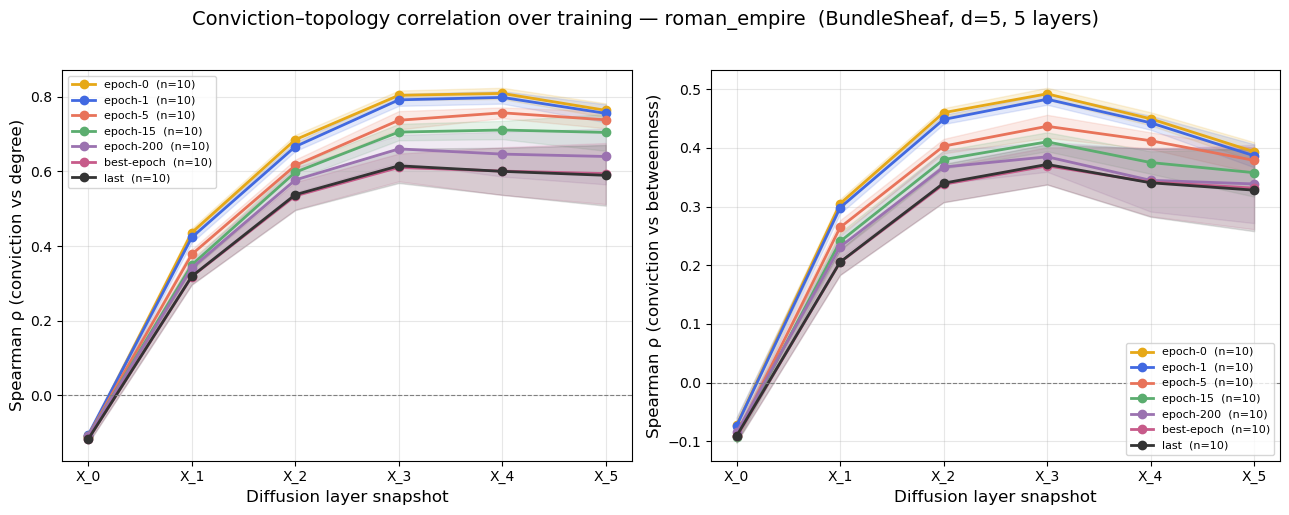

In [5]:
PALETTE = [
    "#E6A817",  # epoch-0
    "#4169E1",  # epoch-1
    "#E8735A",  # epoch-5
    "#5BAD6F",  # epoch-15
    "#9B72B0",  # epoch-200
    "#C75B8A",  # best-epoch
    "#333333",  # last
]

valid         = [c for c in checkpoint_names if c in results]
x             = np.arange(num_snapshots)  # 0 … layers

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

panel_specs = [
    ('rho_deg_mean', 'rho_deg_std', 'Spearman ρ (conviction vs degree)'),
    ('rho_bet_mean', 'rho_bet_std', 'Spearman ρ (conviction vs betweenness)'),
]

for ax, (mean_key, std_key, ylabel) in zip(axes, panel_specs):
    for i, ckpt_name in enumerate(valid):
        res   = results[ckpt_name]
        mu    = res[mean_key]
        sigma = res[std_key]
        color = PALETTE[i % len(PALETTE)]
        label = f"{ckpt_name}  (n={res['n_folds']})"

        ax.plot(x, mu, marker='o', lw=2, color=color, label=label)
        ax.fill_between(x, mu - sigma, mu + sigma, alpha=0.15, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(snapshot_labels, fontsize=10)
    ax.set_xlabel("Diffusion layer snapshot", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.axhline(0, color='grey', lw=0.8, linestyle='--')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')

fig.suptitle(
    f"Conviction–topology correlation over training — {dataset}  "
    f"({model}, d={stalk_dim}, {layers} layers)",
    fontsize=14, y=1.02
)
fig.tight_layout()

os.makedirs("metric_images", exist_ok=True)
out_path = (
    f"metric_images/{dataset}_{model}_d{stalk_dim}_{layers}L_"
    f"Norm_{Norm}_conviction_correlation_checkpoints.pdf"
)
#fig.savefig(out_path, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()